In [1]:
import torch
import segmentation_models_pytorch as smp
from torchinfo import summary
from torchviz import make_dot
from unet import UNet

In [2]:
unet = UNet(in_channels=3, num_classes=1, skip_connections=True)
pretrained = smp.Unet(encoder_name="resnet18", encoder_weights="imagenet", in_channels=3, classes=1)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

## torchinfo — Architecture Summary

In [3]:
print("=" * 80)
print("UNet (from scratch)")
print("=" * 80)
summary(unet, input_size=(1, 3, 512, 512), depth=3, col_names=["input_size", "output_size", "num_params", "kernel_size"])

UNet (from scratch)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
UNet                                     [1, 3, 512, 512]          [1, 1, 512, 512]          --                        --
├─Sequential: 1-1                        [1, 3, 512, 512]          [1, 64, 512, 512]         --                        --
│    └─Conv2d: 2-1                       [1, 3, 512, 512]          [1, 64, 512, 512]         1,792                     [3, 3]
│    └─ReLU: 2-2                         [1, 64, 512, 512]         [1, 64, 512, 512]         --                        --
│    └─Conv2d: 2-3                       [1, 64, 512, 512]         [1, 64, 512, 512]         36,928                    [3, 3]
│    └─ReLU: 2-4                         [1, 64, 512, 512]         [1, 64, 512, 512]         --                        --
├─MaxPool2d: 1-2                         [1, 64, 512, 512]         [1, 64, 256, 256]         --                        2
├─Seque

In [4]:
print("=" * 80)
print("Pretrained UNet (ResNet18 + ImageNet)")
print("=" * 80)
summary(pretrained, input_size=(1, 3, 512, 512), depth=3, col_names=["input_size", "output_size", "num_params", "kernel_size"])

Pretrained UNet (ResNet18 + ImageNet)


Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Kernel Shape
Unet                                          [1, 3, 512, 512]          [1, 1, 512, 512]          --                        --
├─ResNetEncoder: 1-1                          [1, 3, 512, 512]          [1, 3, 512, 512]          --                        --
│    └─Conv2d: 2-1                            [1, 3, 512, 512]          [1, 64, 256, 256]         9,408                     [7, 7]
│    └─BatchNorm2d: 2-2                       [1, 64, 256, 256]         [1, 64, 256, 256]         128                       --
│    └─ReLU: 2-3                              [1, 64, 256, 256]         [1, 64, 256, 256]         --                        --
│    └─MaxPool2d: 2-4                         [1, 64, 256, 256]         [1, 64, 128, 128]         --                        3
│    └─Sequential: 2-5                        [1, 64, 128, 128]         [1, 64, 128, 128]         

## torchviz — Computation Graphs

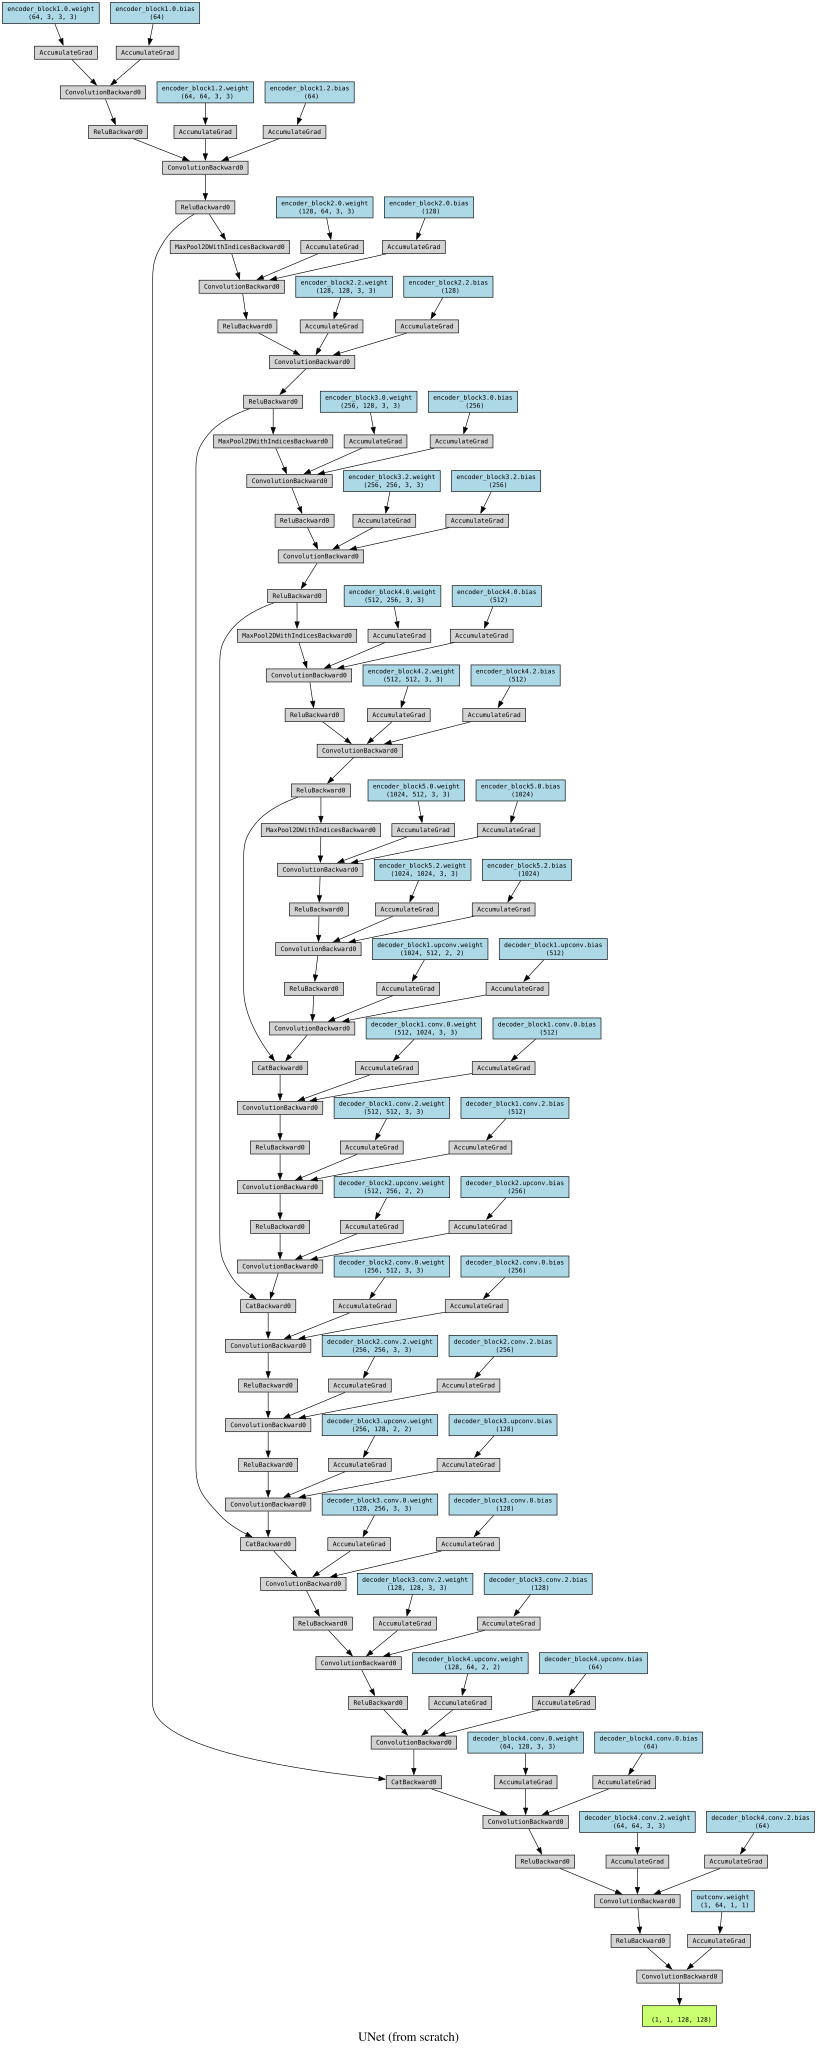

In [5]:
x = torch.randn(1, 3, 128, 128)

y_unet = unet(x)
dot_unet = make_dot(y_unet, params=dict(unet.named_parameters()), show_attrs=False, show_saved=False)
dot_unet.attr(label="UNet (from scratch)", fontsize="20")
dot_unet

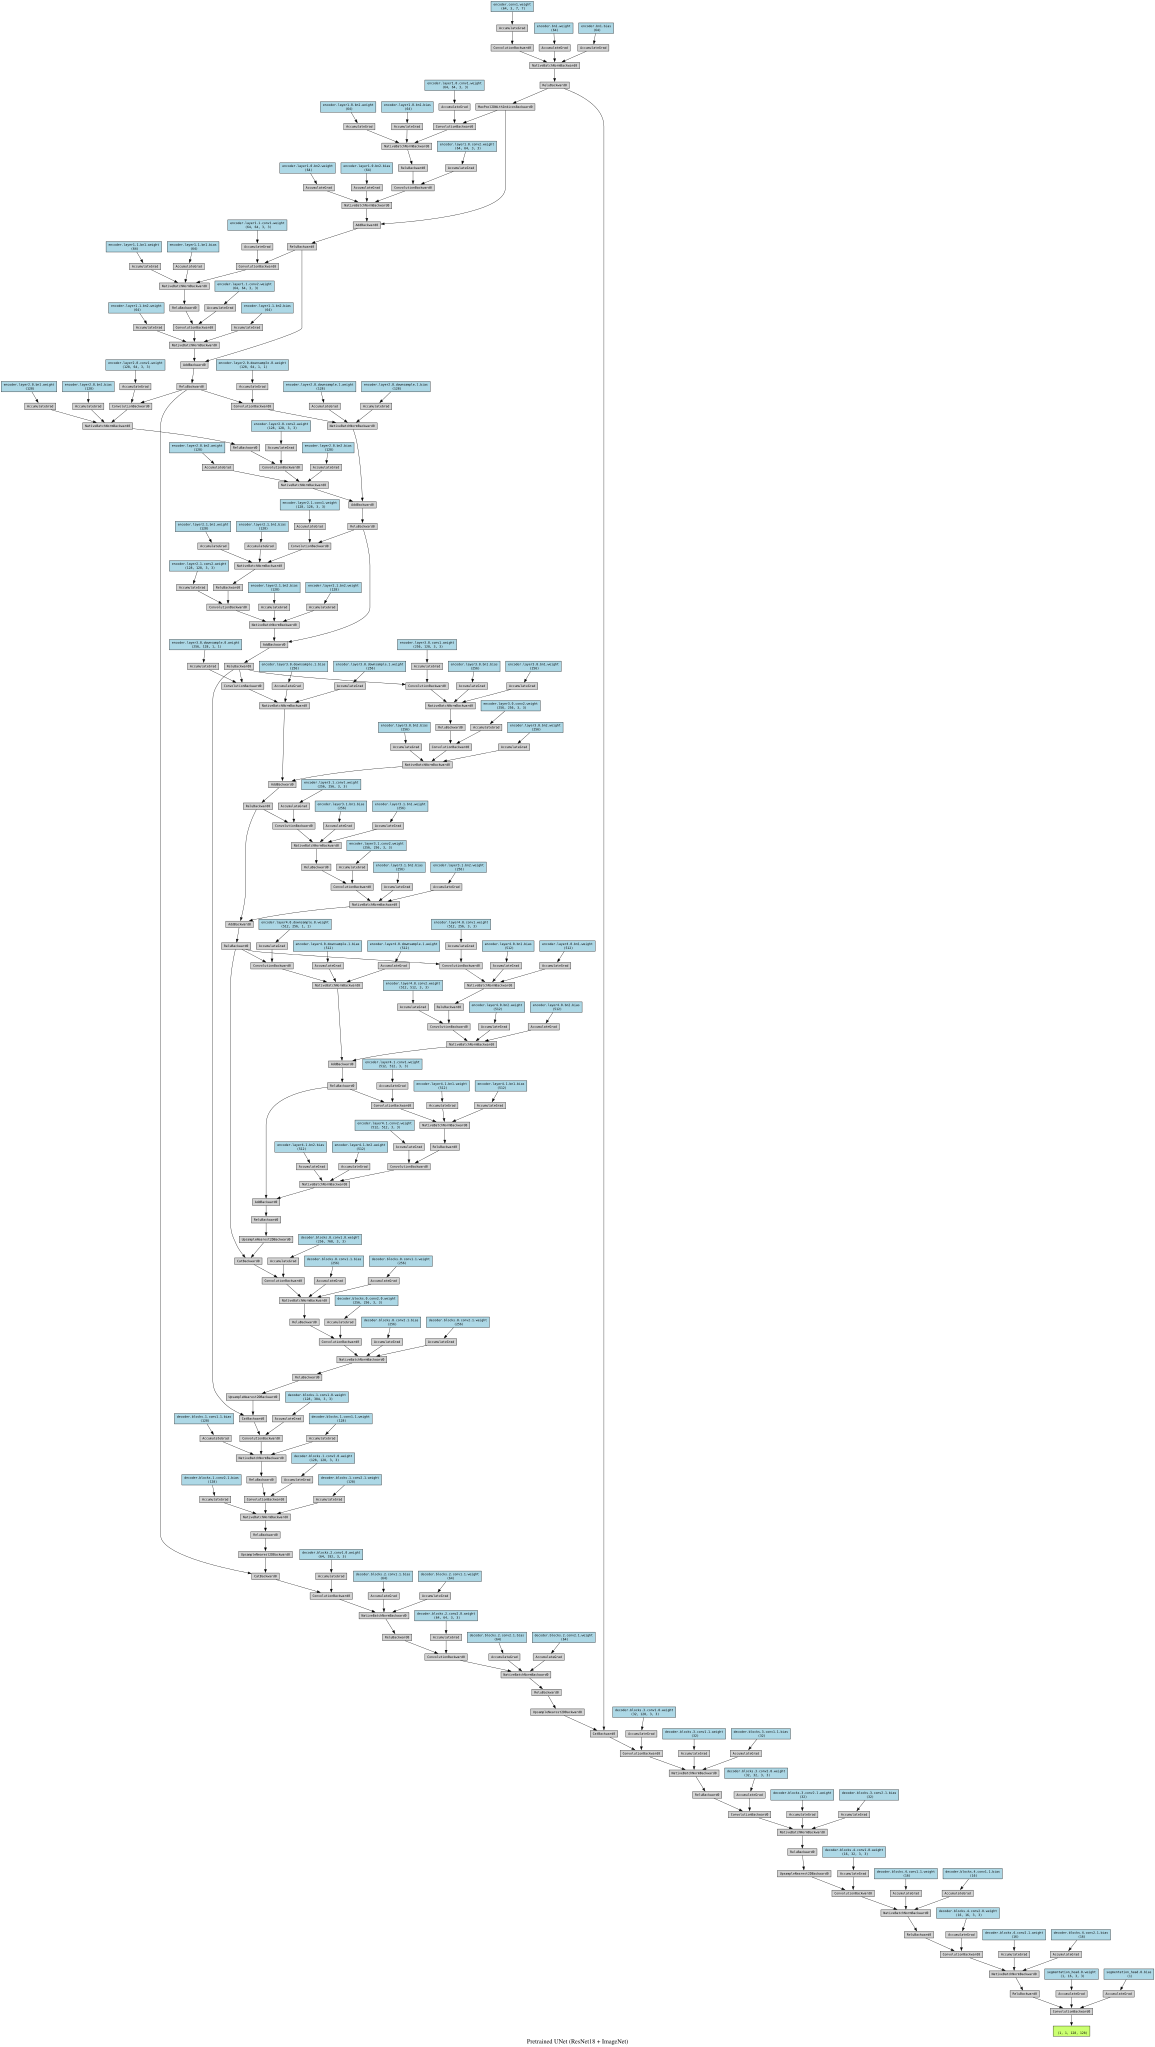

In [6]:
y_pretrained = pretrained(x)
dot_pretrained = make_dot(y_pretrained, params=dict(pretrained.named_parameters()), show_attrs=False, show_saved=False)
dot_pretrained.attr(label="Pretrained UNet (ResNet18 + ImageNet)", fontsize="20")
dot_pretrained

## torchview — Module-Level Graphs

In [7]:
from torchview import draw_graph

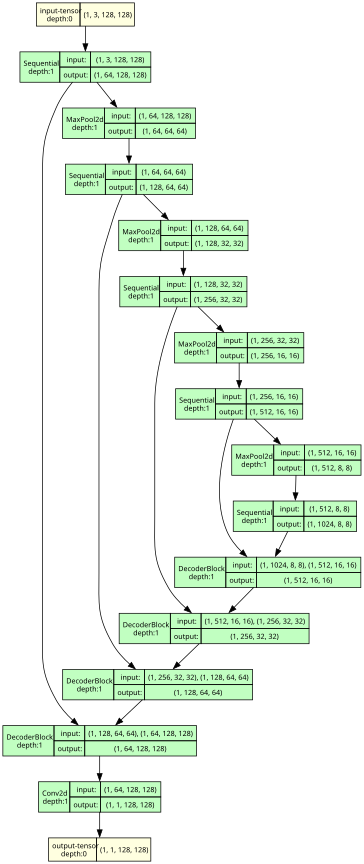

In [14]:
graph_unet = draw_graph(unet, input_size=(1, 3, 128, 128), depth=1, expand_nested=True)
graph_unet.visual_graph

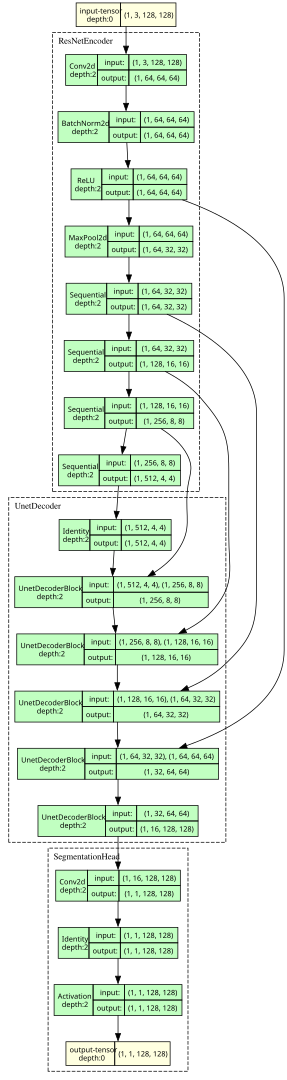

In [16]:
graph_pretrained = draw_graph(pretrained, input_size=(1, 3, 128, 128), depth=2, expand_nested=True)
graph_pretrained.visual_graph